In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-whitegrid')


/tmp/ipykernel_11/3967879655.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


In [2]:
df_train = pd.read_csv("../input/new-york-city-taxi-fare-prediction/train.csv", nrows=1_000_000,parse_dates=["pickup_datetime"])
df_train.head()


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1


In [3]:
df_train.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1000000.000000,1000000.000000,1000000.000000,999990.000000,999990.000000,1000000.000000
mean,11.348079,-72.526640,39.929008,-72.527860,39.919954,1.684924
std,9.822090,12.057937,7.626154,11.324494,8.201418,1.323911
min,-44.900000,-3377.680935,-3116.285383,-3383.296608,-3114.338567,0.000000
25%,6.000000,-73.992060,40.734965,-73.991385,40.734046,1.000000
50%,8.500000,-73.981792,40.752695,-73.980135,40.753166,1.000000
75%,12.500000,-73.967094,40.767154,-73.963654,40.768129,2.000000
max,500.000000,2522.271325,2621.628430,45.581619,1651.553433,208.000000


In [4]:
df_test = pd.read_csv("../input/new-york-city-taxi-fare-prediction/test.csv",parse_dates=["pickup_datetime"])
df_test.head()


,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-10-01 21:26:11.0000001,2010-10-01 21:26:11+00:00,-73.983130,40.761970,-73.994386,40.749236,1
1,2013-10-06 01:38:00.00000083,2013-10-06 01:38:00+00:00,-73.948505,40.753977,-73.808195,40.731952,2
2,2012-03-30 19:13:53.0000001,2012-03-30 19:13:53+00:00,-73.973964,40.791979,-73.979018,40.785544,1
3,2012-02-08 02:57:23.0000001,2012-02-08 02:57:23+00:00,-73.991478,40.738907,-73.907198,40.861572,2
4,2013-12-13 22:56:00.000000237,2013-12-13 22:56:00+00:00,-73.986281,40.740067,-73.933927,40.856781,2


In [5]:
df_test.describe()


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-72.365437,39.854075,-72.355298,39.849902,1.701735
std,10.901230,6.325354,10.928248,6.338538,1.328327
min,-74.178068,-74.000425,-75.437730,-74.009507,0.000000
25%,-73.992274,40.734688,-73.991365,40.733664,1.000000
50%,-73.981978,40.752504,-73.980220,40.753209,1.000000
75%,-73.966718,40.767114,-73.963598,40.768143,2.000000
max,40.790297,41.366138,40.800715,41.056380,6.000000


In [6]:
print('Old size: %d' % len(df_train))
df_train = df_train[df_train.fare_amount>=0]
print('New size: %d' % len(df_train))


Old size: 1000000
New size: 999962


In [7]:
print('Old size: %d' % len(df_train))
df_train = df_train.dropna(how = 'any', axis = 'rows')
print('New size: %d' % len(df_train))


Old size: 999962
New size: 999952


Text(0.5, 0, 'fare $USD')

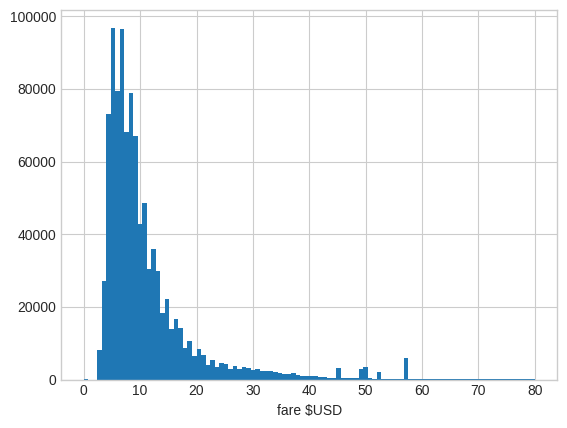

In [8]:
df_train[df_train.fare_amount < 80].fare_amount.hist(bins=100)
plt.xlabel('fare $USD')


In [9]:
df_train['diff_long'] = (df_train.dropoff_longitude - df_train.pickup_longitude).abs()
df_train['diff_long'].describe()


count    999952.000000
mean          0.182548
std           7.676120
min           0.000000
25%           0.005803
50%           0.012447
75%           0.023699
max        4240.388978
Name: diff_long, dtype: float64

In [10]:
df_train['diff_lat'] = (df_train.dropoff_latitude - df_train.pickup_latitude).abs()
df_train['diff_lat'].describe()


count    999952.000000
mean          0.113383
std           8.270898
min           0.000000
25%           0.006592
50%           0.013865
75%           0.026917
max        5486.099433
Name: diff_lat, dtype: float64

In [11]:
print('Old size: %d' % len(df_train))
df_train = df_train[(df_train.diff_long < 5.0) & (df_train.diff_lat < 5.0)]
print('New size: %d' % len(df_train))


Old size: 999952
New size: 997990


In [12]:
df_train['year'] = df_train.pickup_datetime.apply(lambda t: t.year)
df_train['weekday'] = df_train.pickup_datetime.apply(lambda t: t.weekday())
df_train['hour'] = df_train.pickup_datetime.apply(lambda t: t.hour)


In [13]:
df_train.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,diff_long,diff_lat,year,weekday,hour
count,997990.000000,997990.000000,997990.000000,997990.000000,997990.000000,997990.000000,997990.000000,997990.000000,997990.000000,997990.000000,997990.000000
mean,11.341837,-72.583098,39.959231,-72.582209,39.959569,1.684950,0.022506,0.021086,2011.739095,3.039942,13.509711
std,9.801924,10.166602,5.984613,10.166486,5.984640,1.323821,0.038233,0.027717,1.860760,1.949923,6.513913
min,0.000000,-121.391210,-74.016587,-121.391248,-74.035197,0.000000,0.000000,0.000000,2009.000000,0.000000,0.000000
25%,6.000000,-73.992070,40.735032,-73.991394,40.734107,1.000000,0.005792,0.006580,2010.000000,1.000000,9.000000
50%,8.500000,-73.981810,40.752727,-73.980158,40.753195,1.000000,0.012420,0.013832,2012.000000,3.000000,14.000000
75%,12.500000,-73.967157,40.767174,-73.963734,40.768146,2.000000,0.023603,0.026808,2013.000000,5.000000,19.000000
max,500.000000,40.850357,51.084373,40.851027,51.346519,208.000000,4.923874,3.820613,2015.000000,6.000000,23.000000


In [14]:
df_train[['fare_amount', 'hour']].groupby(['hour'], as_index=False).mean().sort_values(by='fare_amount', ascending=False)


,hour,fare_amount
5,5,15.389197
4,4,13.563618
6,6,12.203498
3,3,12.026388
15,15,12.014656
14,14,11.864828
16,16,11.847752
0,0,11.730199
23,23,11.607433
13,13,11.602990


In [15]:
df_train[['fare_amount', 'weekday']].groupby(['weekday'], as_index=False).mean().sort_values(by='fare_amount', ascending=False)


,weekday,fare_amount
6,6,11.632518
3,3,11.501779
4,4,11.387728
0,0,11.385339
2,2,11.280719
1,1,11.216120
5,5,11.022402


In [16]:
df_train[['fare_amount', 'year']].groupby(['year'], as_index=False).mean().sort_values(by='fare_amount', ascending=False)


,year,fare_amount
6,2015,13.016302
5,2014,12.910192
4,2013,12.606738
3,2012,11.175261
2,2011,10.433560
1,2010,10.177292
0,2009,10.041246


In [17]:
def distance(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295 # Pi/180
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 12742 * np.arcsin(np.sqrt(a)) # 2*R*asin...


In [18]:
df_train['distance'] = distance(df_train.pickup_latitude, df_train.pickup_longitude, \
                                      df_train.dropoff_latitude, df_train.dropoff_longitude)


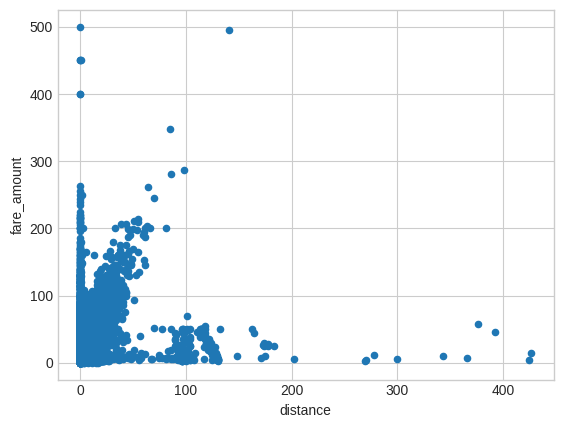

In [19]:
plot = df_train.plot.scatter('distance', 'fare_amount')


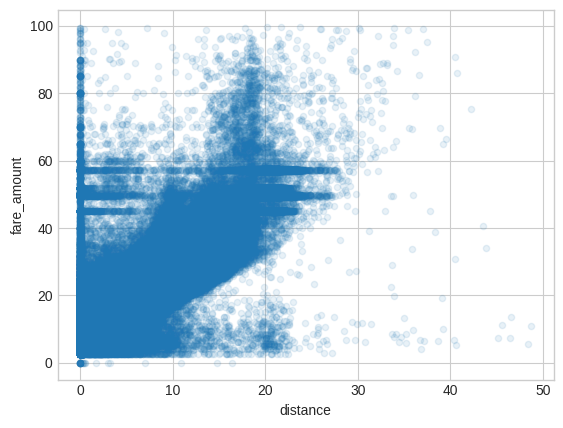

In [20]:
plot = df_train[(df_train.distance < 50) & (df_train.fare_amount < 100)].plot.scatter('distance', 'fare_amount',alpha=0.1)


In [21]:
print('Old size: %d' % len(df_train))
df_train = df_train[(df_train.distance >= 0.1)]
print('New size: %d' % len(df_train))


Old size: 997990
New size: 963705


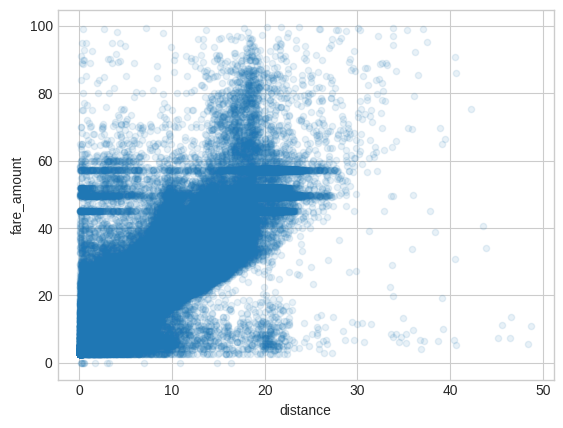

In [22]:
plot = df_train[(df_train.distance < 50) & (df_train.fare_amount < 100)].plot.scatter('distance', 'fare_amount',alpha=0.1)


In [23]:
print('Old size: %d' % len(df_train))
df_train = df_train[(df_train.distance <= 50)]
print('New size: %d' % len(df_train))


Old size: 963705
New size: 963341


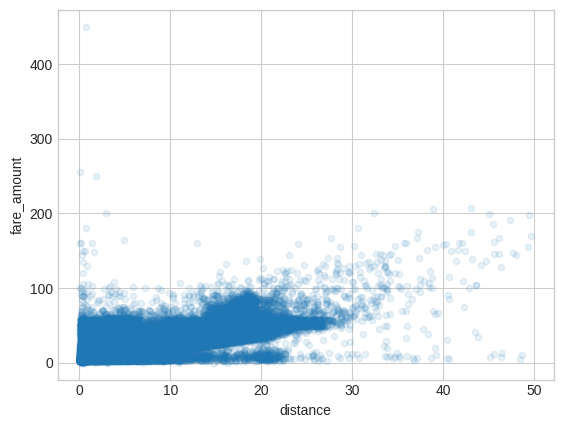

In [24]:
plot = df_train.plot.scatter('distance', 'fare_amount',alpha=0.1)


In [25]:
print('Old size: %d' % len(df_train))
df_train = df_train[(df_train.fare_amount <= 200)]
print('New size: %d' % len(df_train))


Old size: 963341
New size: 963336


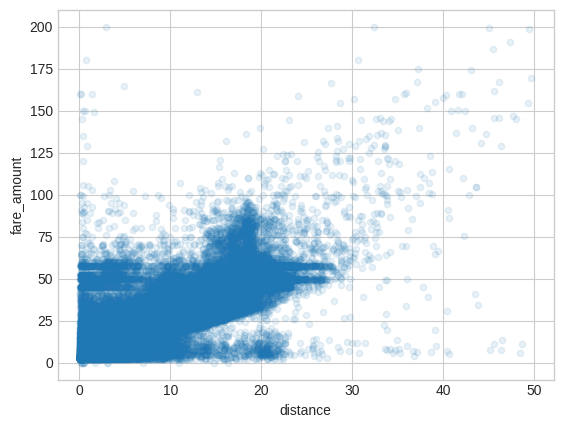

In [26]:
plot = df_train.plot.scatter('distance', 'fare_amount',alpha=0.1)


In [27]:
features = ['year', 'hour', 'distance']
X = df_train[features].values
y = df_train['fare_amount'].values


In [28]:
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LinearRegression
# from sklearn.preprocessing import StandardScaler
# model_lin = Pipeline((
#         ("standard_scaler", StandardScaler()),
#         ("lin_reg", LinearRegression()),
#     ))
# model_lin.fit(X, y)


In [29]:
df_test['year'] = df_test.pickup_datetime.apply(lambda t: t.year)
df_test['hour'] = df_test.pickup_datetime.apply(lambda t: t.hour)
df_test['distance'] = distance(df_test.pickup_latitude, df_test.pickup_longitude, \
                                      df_test.dropoff_latitude, df_test.dropoff_longitude)


In [30]:
X_kaggle_test = df_test[features].values


In [31]:
# y_pred_final = model_lin.predict(XTEST)

# submission = pd.DataFrame(
#     {'key': df_test.key, 'fare_amount': y_pred_final},
#     columns = ['key', 'fare_amount'])
# submission.to_csv('submission.csv', index = False)


In [32]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0,test_size=0.3)

def XGBmodel(x_train,x_test,y_train,y_test):
    matrix_train = xgb.DMatrix(x_train,label=y_train)
    matrix_test = xgb.DMatrix(x_test,label=y_test)
    model=xgb.train(params={'objective':'reg:linear','eval_metric':'rmse'},
                    dtrain=matrix_train,num_boost_round=100, 
                    early_stopping_rounds=100,evals=[(matrix_test,'test')])
    return model

model = XGBmodel(X_train,X_test,y_train,y_test)
prediction = model.predict(xgb.DMatrix(X_kaggle_test), ntree_limit = model.best_ntree_limit)


[0]	test-rmse:7.18021
[1]	test-rmse:5.76036
[2]	test-rmse:4.90771
[3]	test-rmse:4.42552
[4]	test-rmse:4.16394


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [00:45:59] WARNING: /workspace/src/objective/regression_obj.cu:209: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[5]	test-rmse:4.02569
[6]	test-rmse:3.95389
[7]	test-rmse:3.91772
[8]	test-rmse:3.89908
[9]	test-rmse:3.88941
[10]	test-rmse:3.88393
[11]	test-rmse:3.87998
[12]	test-rmse:3.87856
[13]	test-rmse:3.87761
[14]	test-rmse:3.87704
[15]	test-rmse:3.87700
[16]	test-rmse:3.87659
[17]	test-rmse:3.87607
[18]	test-rmse:3.87623
[19]	test-rmse:3.87566
[20]	test-rmse:3.87540
[21]	test-rmse:3.87530
[22]	test-rmse:3.87522
[23]	test-rmse:3.87528
[24]	test-rmse:3.87589
[25]	test-rmse:3.87588
[26]	test-rmse:3.87600
[27]	test-rmse:3.87594
[28]	test-rmse:3.87649
[29]	test-rmse:3.87655
[30]	test-rmse:3.87653
[31]	test-rmse:3.87652
[32]	test-rmse:3.87660
[33]	test-rmse:3.87691
[34]	test-rmse:3.87721
[35]	test-rmse:3.87726
[36]	test-rmse:3.87723
[37]	test-rmse:3.87719
[38]	test-rmse:3.87710
[39]	test-rmse:3.87716
[40]	test-rmse:3.87719
[41]	test-rmse:3.87721
[42]	test-rmse:3.87738
[43]	test-rmse:3.87799
[44]	test-rmse:3.87824
[45]	test-rmse:3.87813
[46]	test-rmse:3.87815
[47]	test-rmse:3.87818
[48]	test-rmse:3

AttributeError: 'Booster' object has no attribute 'best_ntree_limit'

In [33]:
submission = pd.DataFrame({
        "key": df_test['key'],
        "fare_amount": prediction.round(2)
})

submission.to_csv('submission.csv',index=False)
submission


NameError: name 'prediction' is not defined